In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
insurance_data = pd.read_csv("01_insurance.csv")

In [3]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#Create useful and interacted features
X = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns = ["region", "sex", "smoker"], drop_first = True, dtype = int)
#Creating new features

X["bmi_smoker"] = X["bmi"] * X["smoker_yes"]
X["age_smoker"] = X["age"] * X["smoker_yes"]
X.head()

,age,bmi,children,region_northwest,region_southeast,region_southwest,sex_male,smoker_yes,bmi_smoker,age_smoker
0,19,27.900,0,0,0,1,0,1,27.9,19
1,18,33.770,1,0,1,0,1,0,0.0,0
2,28,33.000,3,0,1,0,1,0,0.0,0
3,33,22.705,0,1,0,0,1,0,0.0,0
4,32,28.880,0,1,0,0,1,0,0.0,0


In [5]:
#Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
#Ridge Model
alpha = [0.000000001,0.000005,0.0001,0.0003,0.001,0.1,1,2,3,4,5,10,20,30,40]
error_list = []
for i in alpha:
    ridge_model = Ridge(alpha = i)
    ridge_model.fit(X_train,y_train)
    #prediction
    y_predict = ridge_model.predict(X_test)
    #r2 Score
    r2 = r2_score(y_test,y_predict)
    print(f"r2_score if alpha {i}:",r2)
    error_list.append(r2)

r2_score if alpha 1e-09: 0.8652316979543985
r2_score if alpha 5e-06: 0.8652317040886977
r2_score if alpha 0.0001: 0.8652318206569487
r2_score if alpha 0.0003: 0.8652320660219008
r2_score if alpha 0.001: 0.8652329243520389
r2_score if alpha 0.1: 0.8653475156528512
r2_score if alpha 1: 0.8659186258752841
r2_score if alpha 2: 0.8659693722394074
r2_score if alpha 3: 0.8657441884829877
r2_score if alpha 4: 0.8654018051527211
r2_score if alpha 5: 0.8650163803467926
r2_score if alpha 10: 0.8632100565951497
r2_score if alpha 20: 0.8609481879462305
r2_score if alpha 30: 0.8596866106630394
r2_score if alpha 40: 0.8588754314186183


<Axes: >

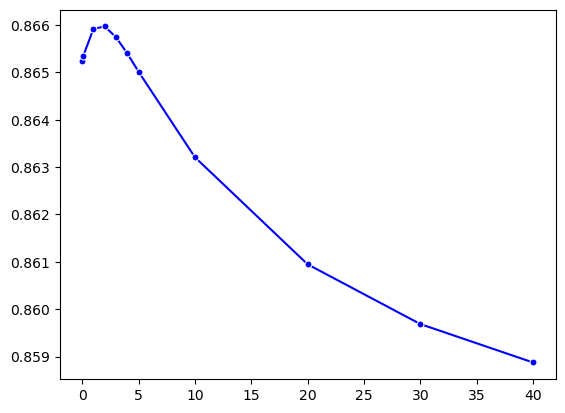

In [7]:
sns.lineplot(
    x = alpha,
    y = error_list,
    marker = ".",
    markersize=10,
    color = "blue"
)

In [11]:
#using RidgeCV model
from  sklearn.linear_model import RidgeCV
alpha = [0.000000001,0.000005,0.0001,0.0003,0.001,0.1,1,2,3,4,5,10,20,30,40]

ridgecv_model = RidgeCV(
    alphas = alpha,
    cv= 5,
)
ridgecv_model.fit(X_train,y_train)
print("Best alpha:",ridgecv_model.alpha_)

Best alpha: 0.001


In [9]:
#prediction
y_predict = ridgecv_model.predict(X_test)

In [10]:
#r2_score
r2 = r2_score(y_test,y_predict)
print("Mean Square Error alpha:",r2)

Mean Square Error alpha: 0.8652329243520389
